# Breast Ultrasound Image Classification using BUSI Dataset

In [9]:
!pip install tensorflow seaborn scikit-learn matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

In [14]:
dataset_path = "Breast ultrasound/Dataset_BUSI_with_GT"

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 625 images belonging to 3 classes.
Found 155 images belonging to 3 classes.


In [16]:
model = Sequential([

Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
BatchNormalization(),
MaxPooling2D(2,2),

Conv2D(64,(3,3),activation='relu'),
BatchNormalization(),
MaxPooling2D(2,2),

Conv2D(128,(3,3),activation='relu'),
BatchNormalization(),
MaxPooling2D(2,2),

Flatten(),

Dense(128,activation='relu'),
Dropout(0.5),

Dense(3,activation='softmax')

])

model.compile(
optimizer=Adam(learning_rate=0.0001),
loss='categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 222, 222, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 109, 109, 64)     256       
 hNormalization)                                                 
                                                        

In [17]:
history = model.fit(
train_generator,
validation_data=validation_generator,
epochs=20
)

Epoch 1/20
20/20 [==============================] - 31s 1s/step - loss: 2.6158 - accuracy: 0.5040 - val_loss: 2.5875 - val_accuracy: 0.2710
Epoch 2/20
20/20 [==============================] - 20s 1s/step - loss: 0.9480 - accuracy: 0.6032 - val_loss: 7.9698 - val_accuracy: 0.2710
Epoch 3/20
20/20 [==============================] - 22s 1s/step - loss: 0.9151 - accuracy: 0.6352 - val_loss: 12.6435 - val_accuracy: 0.2710
Epoch 4/20
20/20 [==============================] - 26s 1s/step - loss: 0.8718 - accuracy: 0.6224 - val_loss: 16.2778 - val_accuracy: 0.2710
Epoch 5/20
20/20 [==============================] - 22s 1s/step - loss: 0.8659 - accuracy: 0.6416 - val_loss: 19.6684 - val_accuracy: 0.2710
Epoch 6/20
20/20 [==============================] - 26s 1s/step - loss: 0.8495 - accuracy: 0.6688 - val_loss: 22.9457 - val_accuracy: 0.2710
Epoch 7/20
20/20 [==============================] - 23s 1s/step - loss: 0.8149 - accuracy: 0.6544 - val_loss: 25.3353 - val_accuracy: 0.2710
Epoch 8/20
20/2

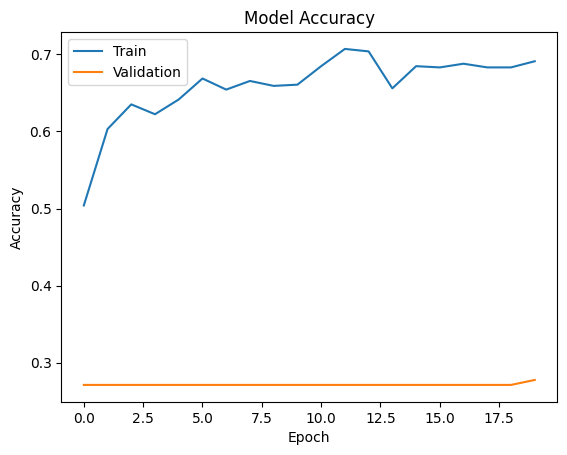

In [18]:
plt.figure()

plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.savefig("accuracy_graph.png")

plt.show()

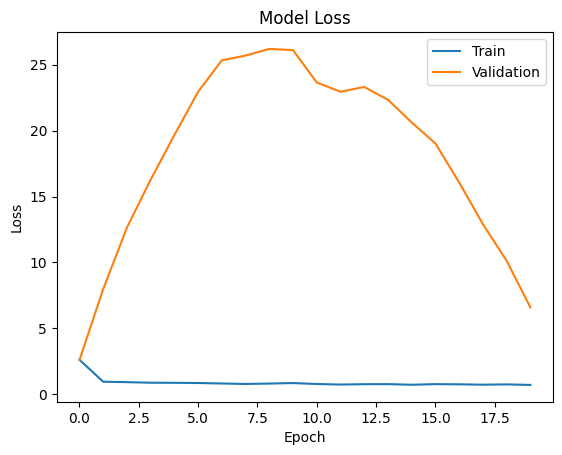

In [19]:
plt.figure()

plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.savefig("loss_graph.png")

plt.show()

5/5 [==============================] - 2s 425ms/step


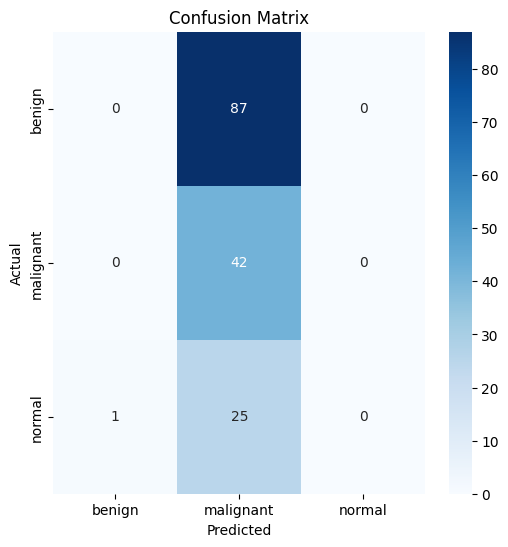

In [22]:
validation_generator.reset()

pred = model.predict(validation_generator)
pred_classes = np.argmax(pred,axis=1)

true_classes = validation_generator.classes
labels = list(validation_generator.class_indices.keys())

cm = confusion_matrix(true_classes,pred_classes)

plt.figure(figsize=(6,6))

sns.heatmap(
cm,
annot=True,
fmt="d",
cmap="Blues",
xticklabels=labels,
yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()

In [23]:
print(classification_report(true_classes,pred_classes,target_names=labels))

              precision    recall  f1-score   support

      benign       0.00      0.00      0.00        87
   malignant       0.27      1.00      0.43        42
      normal       0.00      0.00      0.00        26

    accuracy                           0.27       155
   macro avg       0.09      0.33      0.14       155
weighted avg       0.07      0.27      0.12       155



c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod